# **<u> Do abortion restrictions cause a decrease in abortions?**

In [22]:
# Data Analysis packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics Packages
import scipy.stats as stats
import statsmodels.api as sm

### **Dataset Used:**

https://osf.io/k4x7t/files/kqb9n - Link to Dataset

https://www.guttmacher.org/monthly-abortion-provision-study?state=US - Parent Website

### **Dataset Description:**

**Title:** Monthly Abortion Provision Study

**Description:** The Monthly Abortion Provision Study (https://www.guttmacher.org/monthly-abortion-provision-study) produces national and state estimates of the number of abortions provided in states without total bans in the United States. This ongoing project reveals current trends and aims to put timely data in the hands of policymakers, advocates and providers. Details on how to access project files and citation information can be found in Wiki below,

**Date created:** August 31, 2023

**Date modified:** July 21, 2026

**Contributors:** Isaac Maddow-Zimet, Isabel DoCampo, Rachel Jones, Ava Braccia, Mariah Menanno, Aisiri Murulidhar, Priscille Osias, Lauren Mitchell, Jesse Philbin

### **Innitial Assumption:**
- Do abortion restrictions cause a decrease in number of abortions?

### **Linear Regression for Causal Inferrence:**

> $y$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_{it}$

$y$ = The outcome variable. The dependent variable.

$\beta_0$ = The outcome of the control group.

$\beta_1$ = The average difference in the change of the outcome between the treated and controlled groups.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- Median Number of Abortions.
- This is the median number of abortions measured per month per state since the beginning of 2023.
- The reason the median is used is because the number of abortions is an estimate since the true number is impossible to determine.
- There is an upper bound and a lower bound of abortions, and so the median is the middle value between these two.

### **Treatment Variable:**
- restricted state, where 1 = state with abortion restrictions, and 0 = state with no abortion restrictions.
- Since 2023 and the abolishment of Roe V. Wade, which was the court case legalizing abortion in the United States, there are 13 states with a complete ban on abortion after conception of a human fetus.
- These states include Alabama, Arkansas, Idaho, Indiana, Kentucky, Louisiana, Mississippi, North Dakota, Oklahoma, South Dakota, Tennessee, Texas, and West Virginia.
- States with a ban on abortions after 6 weeks from conception are Florida, Georgia, Iowa, and South Carolina.
- There are 2 states with a ban on abortion after 12 weeks of conception, which are Nebraska and North Carolina.
- Finally, the state with a ban on abortion after 18 weeks of conception is Utah.
- Additionally, 3 American territories also have bans. They are American Samoa and Northern Mariana Islands both with a total ban after conception, and Guam with a ban after 13 weeks.
- For some reason, the dataset only has Guam abortion data, so Guam is the only one included in the analysis. American Samoa and North Mariana Islands will not be included.
- In all other states and territories, abortion is completely legal.
- However, there are an additional 2 states with an 'in flux' or 'disputed' abortion restrictions. Missouri abortion is disputed after conception, and Montana has banned any sort of legal blocking for abortions.
- Missouri and Montana will be viewed as part of the control group. That is, abortions in these states will be considered legal in this analysis since they technically have not made it illegal.

    - https://www.theguardian.com/us-news/ng-interactive/2024/jul/29/abortion-laws-bans-by-state - Information on states with/without abortion bans

    - https://en.wikipedia.org/wiki/Roe_v._Wade - Further Information of Roe V. Wade Supreme Court case. This overturned case is the reason why abortion has been banned in many US states.

### **Possible Cofounders:**
- Month and Year.
- States dummy variables. k - 1 states.

### **Linear Regression Equation for Problem:**
> Median Number of Abortions = $\beta_0$ + $\beta_1$ (Restricted State, 1 = State with complete/partial bans on abortions, 0 = state with legal abortions) + $\beta_2$ (Month) + $\beta_3$ (Year) + $\beta_{k-1}$ (k - 1 States) + $\epsilon_i$

---

## <u> **Importing and Cleaning Data:**

In [23]:
df = pd.read_csv("C:\BROCK U COURSE DOCS\DataSets\MonthlyAbortionProvisionMonthly.csv")
df

,state,month,median,lowerbound,upperbound,source,notes,publishdate
0,US,2023-01-15,88040,86880,89450,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
1,US,2023-02-15,81570,80490,82890,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
2,US,2023-03-15,94070,92820,95570,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
3,US,2023-04-15,84410,83260,85740,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
4,US,2023-05-15,87220,86070,88600,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
...,...,...,...,...,...,...,...,...
2089,WY,2025-12-15,60,50,70,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
2090,WY,2026-01-15,70,60,80,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
2091,WY,2026-02-15,60,50,70,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026
2092,WY,2026-03-15,50,50,70,https://www.guttmacher.org/monthly-abortion-pr...,All estimates rounded to nearest 10. Estimates...,07-21-2026


In [24]:
df.duplicated().sum()

np.int64(0)

> No duplicated rows.

In [25]:
df.isna().sum()

state          0
month          0
median         0
lowerbound     0
upperbound     0
source         0
notes          0
publishdate    0
dtype: int64

> No NaN values in any columns.

In [26]:
df = df.drop(labels= ['lowerbound', 'upperbound', 'source', 'notes', 'publishdate'], axis= 1)

> Removed the unnecessary columns 'lowerbound', 'upperbound', 'source', 'notes', 'publishdate'.

In [27]:
df = df[(df['state'] != 'US') & (df['state'] != 'States with total bans') & (df['state'] != 'States without total bans')]

> Removed all rows that acted as information summary rows of the entire dataset. We want the individual data points on the specific states, not the overall data on abortion in the entire country.

In [28]:
df['year'] = pd.to_datetime(df['month']).dt.year
df['month'] = pd.to_datetime(df['month']).dt.month

> Converted the month column to month integer data type. Also created a year column which contains the year as an integer data type.

In [29]:
df['restrictions'] = df['state'].isin([
    'AL', 'AS', 'AR', 'ID', 'IN', 
    'KY', 'LA', 'MS', 'ND', 'MP', 
    'OK', 'SD', 'TN', 'TX', 'WV', 
    'FL', 'GA', 'IA', 'SC', 'NE', 
    'NC', 'GU', 'UT']).astype(int)

df

,state,month,median,year,restrictions
120,AK,1,120,2023,0
121,AK,2,130,2023,0
122,AK,3,130,2023,0
123,AK,4,100,2023,0
124,AK,5,150,2023,0
...,...,...,...,...,...
2089,WY,12,60,2025,0
2090,WY,1,70,2026,0
2091,WY,2,60,2026,0
2092,WY,3,50,2026,0


> The states and territories (Guam) that do have either complete or partial bans on abortions are the treated 1. The states that have kept abortions legal are the controled 0. 

## <u> **Linear Regression Model:**

In [30]:
y = df['median']

x = df[['restrictions', 'month', 'year']]
x = sm.add_constant(x)

> Getting x and y variables for model. Also adding constant onto x.

In [31]:
state = pd.get_dummies(df['state'], drop_first= True).astype(int)

x = pd.merge(x, state, left_index= True, right_index= True)

> Getting the state dummy variables and merging them to x on the index.

In [32]:
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 median   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     3559.
Date:                Sun, 16 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:48:39   Log-Likelihood:                -13962.
No. Observations:                1974   AIC:                         2.803e+04
Df Residuals:                    1921   BIC:                         2.833e+04
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -5.203e+04   1.41e+04     -3.691      0.000   -7.97e+04   -2.44e+04
restrictions   891.3998     44.758     19.916      0.000     803.621     979.179
month          -14.1265      1.917     -7.367      0.000     -17.887     -10.366
year            25.8159      6.963      3.707      0.000      12.159      39.472
AL            -523.0322     48.345    -10.819      0.000    -617.846    -428.218
AR            -766.2675     48.345    -15.850      0.000    -861.082    -671.453
AZ            1246.7500     64.695     19.271      0.000    1119.870    1373.630
CA            1.518e+04     64.695    234.651      0.000    1.51e+04    1.53e+04
CO            1915.5000     64.695     29.608      0.000    1788.620    2042.380
CT            1109.0000     64.695     17.142      0.000     982.120    1235.880
DC             525.2500     64.695      8.119      0.000     398.370     652.130
DE             183.7500     64.695      2.840      0.005      56.870     310.630
FL            5298.1002     44.758    118.372      0.000    5210.321    5385.879
GA            1957.1002     44.758     43.726      0.000    1869.321    2044.879
HI             178.2500     64.695      2.755      0.006      51.370     305.130
IA            -738.8998     44.758    -16.509      0.000    -826.679    -651.121
ID            -966.5616     48.345    -19.993      0.000   -1061.376    -871.748
IL            7494.0000     64.695    115.836      0.000    7367.120    7620.880
IN            -652.3998     44.758    -14.576      0.000    -740.179    -564.621
KS            1584.0000     64.695     24.484      0.000    1457.120    1710.880
KY            -783.3263     48.345    -16.203      0.000    -878.140    -688.512
LA            -361.2675     48.345     -7.473      0.000    -456.082    -266.453
MA            1711.5000     64.695     26.455      0.000    1584.620    1838.380
MD            3158.0000     64.695     48.814      0.000    3031.120    3284.880
ME              84.0000     64.695      1.298      0.194     -42.880     210.880
MI            3036.5000     64.695     46.936      0.000    2909.620    3163.380
MN            1192.2500     64.695     18.429      0.000    1065.370    1319.130
MO              61.5000     64.695      0.951      0.342     -65.380     188.380
MS            -591.2675     48.345    -12.230      0.000    -686.082    -496.453
MT              69.7500     64.695      1.078      0.281     -57.130     196.630
NC            2937.8502     44.758     65.639      0.000    2850.071    3025.629
ND           -1008.8998     44.758    -22.541      0.000   -1096.679    -921.121
NE            -757.3998     44.758    -16.922      0.000    -845.179    -669.621
NH              75.5000     64.695      1.167      0.243     -51.380     202.380
NJ            4873.2500     64.695     75.327      0.000    4746.370    5000.130
NM   

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> Median Number of Abortions = -5.203e+04 + 891.3998 (Restricted State, 1 = State with complete/partial bans on abortions, 0 = state with legal abortions) -14.1265 (Month) + 25.8159 (Year) + $\beta_{k-1}$ (k - 1 States) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: Population average difference in the outcome between states that have banned abortions (treated = 1) and states that have kept abortions legal (controlled = 0) $\beta_1$ = 0

Ha: Population average difference in the outcome between states that have banned abortions (treated = 1) and states that have kept abortions legal (controlled = 0) $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE[$\beta_1$]

t-stat = (891.3998 - 0) / 44.758

t-stat = 19.916

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value < 0.0001

$\alpha$ = 0.05

=> p-value < $\alpha$

=> <0.0001 < 0.05

=> We reject the null hypothesis; Population average difference in the outcome between states that have banned abortions (treated = 1) and states that have kept abortions legal (controlled = 0) $\beta_1$ != 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_1$ - (t[0.05] * SE), $\beta_1$ + (t[0.05] * SE)]

Confidence Interval = [891.3998 - (1.96 * 44.758), 891.3998 + (1.96 * 44.758)]

Confidence Interval = [803.621, 979.179]

=> Confidence interval does not contains zero, and therefore these results confirm the hypothesis test that $\beta_1$ != 0.

### **Description, Reasoning, and Summary:**
- The linear regression model does not confirm the relationship of the original assumption, which states that implementing abortion restrictions will decrease the number of abortions.
- The average difference in the change between the states that have banned abortions (treated = 1) and the states that have kept abortions legal (controlled = 0) is 891.3998.
- This is known as the average treatment effect ATE, and it can be interpreted as the average *increase by 891.4* in the median number of abortions if a state restricts abortions.
- The relationship may also be interpreted as causal since the ATE is statistically significant. However, this does not automatically mean the relationship is in fact significant.
- The difference between the test statistic and zero, given the standard error, is very high.
- This means that the probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true, is very low.
- This is because, under the assumption the null hypothesis is in fact true, the sample data does not confirm the null to be true and rejects the null hypothesis.
- The difference is so large that the ATE cannot possibly be equal to zero and there must be a relationship between the outcome and the ATE.
- The sample ATE does not confirm the truth of the null hypothesis, and the null hypothesis does not accuratly represent the sample data.
- So, we must reject the null hypothesis for the alternative hypothesis. The population average difference in the outcome between states that have banned abortions (treated = 1) and states that have kept abortions legal (controlled = 0) $\beta_1$ != 0.
- Therefore, we can possibly infer causality from the model data generated. However, we cannot confirm the true existance of a causal effect while holding years, months, and state dummy variables constant, since we cannot possibly control for *all* cofounders.
- Many potentially significant confounders that possibly exist have been controlled for by implementing individual states and also time variables into the regression.
- This means we can possibly conclude this relationship is infact causal; a state that introduces partial or complete restrictions over abortions possibly causes an increase of 891.4 to median abortions.

---

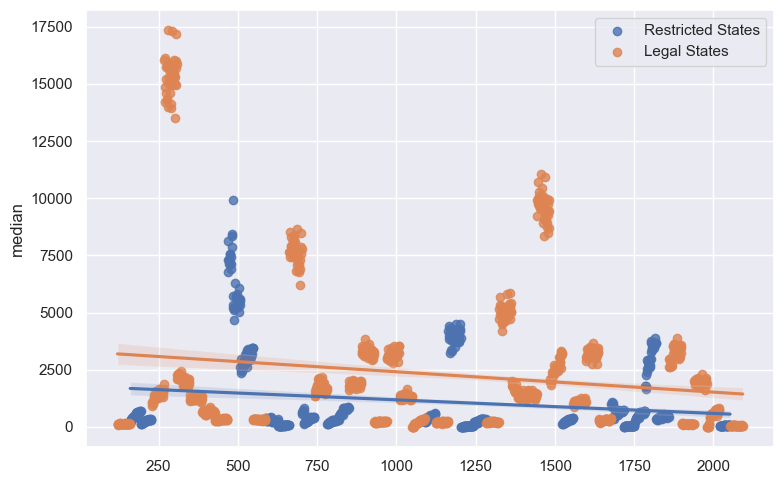

In [37]:
plt.figure(figsize= (8, 5))
sns.set_theme('notebook')

sns.regplot(data= df, x= df[df['restrictions'] == 1].index, y= df[df['restrictions'] == 1]['median'], label= 'Restricted States')
sns.regplot(data= df, x= df[df['restrictions'] == 0].index, y= df[df['restrictions'] == 0]['median'], label= 'Legal States')

plt.legend()
plt.tight_layout()
plt.show()

> This is a regression between the median abortion rates, and the index (which is basically the state). This is the regression before controlling for individual states.